In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo
from sklearn.decomposition import FactorAnalysis

In [2]:
data = pd.read_csv("Healthcare_Imputation.csv")

numeric_data = data.drop(columns=['Country', 'Year'])

numeric_data_standardized = (numeric_data - numeric_data.mean()) / numeric_data.std()

pca = PCA()
pca.fit(numeric_data_standardized)

explained_variance_ratio = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

for i, var in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {var * 100:.2f}% variance explained")

PC1: 39.10% variance explained
PC2: 22.26% variance explained
PC3: 17.57% variance explained
PC4: 5.07% variance explained
PC5: 4.36% variance explained
PC6: 3.95% variance explained
PC7: 3.02% variance explained
PC8: 1.92% variance explained
PC9: 1.08% variance explained
PC10: 0.58% variance explained
PC11: 0.43% variance explained
PC12: 0.20% variance explained
PC13: 0.18% variance explained
PC14: 0.17% variance explained
PC15: 0.11% variance explained
PC16: 0.00% variance explained
PC17: 0.00% variance explained
PC18: 0.00% variance explained


#### Implementing Factor Analysis

In [3]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(numeric_data)

kmo_all,kmo_model=calculate_kmo(df_scaled)
kmo_model

C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


0.8696854640333332

In [4]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer()
fa.fit(df_scaled)
eigen_values, vectors = fa.get_eigenvalues()
eigen_values

C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([7.03833651e+00, 4.00741441e+00, 3.16348928e+00, 9.11992384e-01,
       7.84856808e-01, 7.10931881e-01, 5.43054889e-01, 3.45576629e-01,
       1.94006715e-01, 1.04339568e-01, 7.82534511e-02, 3.57410887e-02,
       3.19460565e-02, 2.99535419e-02, 2.01029308e-02, 1.84829452e-06,
       1.38838666e-06, 6.18504044e-07])

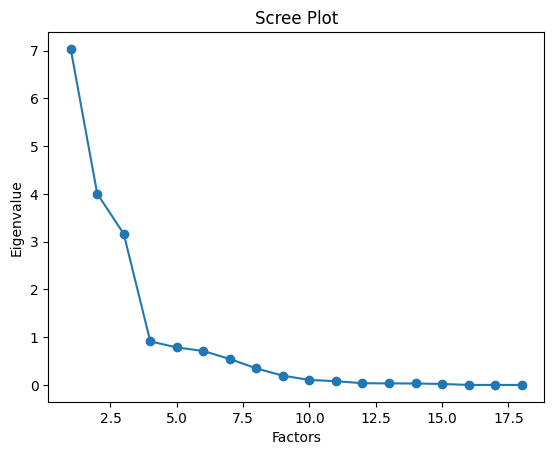

In [5]:
import matplotlib.pyplot as plt
plt.scatter(range(1,df_scaled.shape[1]+1),eigen_values)
plt.plot(range(1,df_scaled.shape[1]+1),eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.show()

In [6]:
columns_for_fa = [
        'LE_at_birth','Doctors_Per_10000','Access_to_Electricity','Carbon_dioxide_emissions_per_capita_production_tonnes',
        'Gender_Development_Index','Gender_Inequality_Index','Human_Development_Index','Health_Care_Index','Crime_Index'
]

data_filled = data[columns_for_fa]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_filled)

fa = FactorAnalysis(n_components=1)

factor_scores = fa.fit_transform(data_scaled)

data['QOLI_Index_FA'] = factor_scores.round(3)

pca = PCA(n_components=1)
pca_scores = pca.fit_transform(data_scaled)
data['QOLI_Index_PCA'] = pca_scores.round(3)

data.to_csv("QOLI_Index.csv", index=False)